# Zimbabwe Real Estate Price Prediction System
## Phase 5 — Hyperparameter Optimisation (Optuna + XGBoost)

**Input :** `data/processed/properties_features.csv`
**Output:** `models/xgb_tuned.pkl` · `models/best_params.json` · 4 diagnostic charts

### What This Notebook Does
1. Runs **100 Optuna trials** to find the best XGBoost hyperparameters using 5-fold CV
2. Compares tuned vs baseline metrics side-by-side
3. Generates Optuna diagnostic plots (optimization history, param importance, slice, contour)
4. Saves the tuned model and parameters for Phase 6 (SHAP) and Phase 8 (Streamlit)

### Issues Fixed from Uploaded Draft
| Issue | Fix Applied |
|-------|-------------|
| `TARGET = 'price'` then `X = df.drop(columns=[TARGET])` — drops all other cols too | Use explicit `SAFE_FEATURES` list; `y = log_price` |
| File paths `../models/` | Corrected to `models/` |
| Missing cross-validation object in objective function | `cv` object passed via closure |
| Optuna diagnostics used plotly (Kaggle-unfriendly) | Replaced with matplotlib static charts |
| SHAP code mixed into Phase 5 | Moved to `06_shap_explainability.ipynb` |


## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
                     'axes.grid':True,'grid.alpha':0.4,'font.family':'DejaVu Sans'})
PALETTE = ['#1A1A2E','#E94560','#27AE60','#F39C12','#2980B9','#8E44AD']

FIG_DIR = 'reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs('models', exist_ok=True)

def save(name):
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

RANDOM_STATE = 42
print('Setup complete. Optuna version:', optuna.__version__)

Setup complete. Optuna version: 4.9.0


---
## 2. Load Data & Build Leakage-Free Feature Matrix

In [2]:
# ── Load feature-engineered dataset ─────────────────────────────────────────
PATHS = [
    'data/processed/properties_features.csv',
    'data/processed/properties_clean.csv',
    'property_phase1_engineered.csv',
]
df = None
for p in PATHS:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f'Loaded: {p}  ({df.shape[0]:,} rows x {df.shape[1]} cols)')
        break
if df is None:
    raise FileNotFoundError('Run Phase 2 + 3 notebooks first to generate properties_features.csv')

# ── Add log_price if missing ──────────────────────────────────────────────────
if 'log_price' not in df.columns:
    df['log_price'] = np.log1p(df['price'])

# ── Add Phase 3 features if missing (running standalone) ─────────────────────
AMENITY_COLS = ['has_pool','has_solar','has_borehole','has_garage',
                'has_garden','has_security','has_inverter','has_generator']
for col in AMENITY_COLS:
    if col in df.columns:
        df[col] = df[col].astype(int)

if 'total_amenities' not in df.columns:
    df['total_amenities'] = df[AMENITY_COLS].sum(axis=1)
if 'room_density' not in df.columns:
    df['room_density'] = (df['bedrooms'] / df['floor_area']).replace([np.inf,-np.inf], np.nan)
if 'floor_to_land_ratio' not in df.columns:
    df['floor_to_land_ratio'] = (df['floor_area'] / df['land_size']).replace([np.inf,-np.inf], np.nan)
if 'bed_bath_ratio' not in df.columns:
    df['bed_bath_ratio'] = (df['bedrooms'] / df['bathrooms'].replace(0,np.nan)).replace([np.inf,-np.inf], np.nan)
if 'listings_per_region' not in df.columns:
    df['listings_per_region'] = df.groupby('region')['price'].transform('count')
if 'listings_per_suburb' not in df.columns:
    df['listings_per_suburb'] = df.groupby('suburb')['price'].transform('count')
if 'house_category_encoded' not in df.columns:
    def get_cat(ht):
        if pd.isna(ht): return 'House'
        ht = str(ht).lower()
        if 'townhouse' in ht or 'complex' in ht: return 'Townhouse'
        if 'flat' in ht or 'apartment' in ht: return 'Flat'
        if 'unit' in ht: return 'Unit'
        return 'House'
    df['house_category'] = df['house_type'].apply(get_cat) if 'house_type' in df.columns else 'House'
    df['house_category_encoded'] = df['house_category'].map({'House':0,'Townhouse':1,'Flat':2,'Unit':3}).fillna(0).astype(int)
if 'furnished' in df.columns:
    df['furnished'] = df['furnished'].astype(int)

print('Feature prep complete.')

Loaded: data/processed/properties_features.csv  (1,985 rows x 53 cols)
Feature prep complete.


In [3]:
# ── Define the exact same leakage-free feature set as Phase 4 ────────────────
SAFE_FEATURES = [
    'bedrooms', 'bathrooms', 'floor_area', 'land_size', 'furnished',
    'has_pool', 'has_solar', 'has_borehole', 'has_garage', 'has_garden',
    'has_security', 'has_inverter', 'has_generator',
    'house_category_encoded',
    'total_amenities', 'energy_score', 'amenity_score', 'modern_amenities',
    'maintenance_burden', 'room_density', 'floor_to_land_ratio',
    'bed_bath_ratio', 'size_ratio',
    'listings_per_region', 'listings_per_suburb'
]

# Verify presence and fill any remaining nulls with median
missing_feats = [f for f in SAFE_FEATURES if f not in df.columns]
if missing_feats:
    print(f'WARNING - Missing features: {missing_feats}')
    SAFE_FEATURES = [f for f in SAFE_FEATURES if f in df.columns]

for col in SAFE_FEATURES:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# ── Build X and y ─────────────────────────────────────────────────────────────
X = df[SAFE_FEATURES].copy()
y = df['log_price'].copy()

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Nulls in X: {X.isnull().sum().sum()}')
print(f'y range : {y.min():.3f} - {y.max():.3f}  (log scale)')
print(f'Price range: ${np.expm1(y.min()):,.0f} - ${np.expm1(y.max()):,.0f}')
print(f'Features ({len(SAFE_FEATURES)}): {SAFE_FEATURES}')

X shape : (1985, 25)
y shape : (1985,)
Nulls in X: 0
y range : 8.517 - 14.403  (log scale)
Price range: $5,000 - $1,800,000
Features (25): ['bedrooms', 'bathrooms', 'floor_area', 'land_size', 'furnished', 'has_pool', 'has_solar', 'has_borehole', 'has_garage', 'has_garden', 'has_security', 'has_inverter', 'has_generator', 'house_category_encoded', 'total_amenities', 'energy_score', 'amenity_score', 'modern_amenities', 'maintenance_burden', 'room_density', 'floor_to_land_ratio', 'bed_bath_ratio', 'size_ratio', 'listings_per_region', 'listings_per_suburb']


---
## 3. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test : {X_test.shape[0]:,} rows')
print(f'CV   : 5-fold, shuffled, random_state={RANDOM_STATE}')

Train: 1,588 rows
Test : 397 rows
CV   : 5-fold, shuffled, random_state=42


---
## 4. Baseline XGBoost (Phase 4 Default Params)

In [5]:
# ── Establish baseline before tuning ─────────────────────────────────────────
BASELINE_PARAMS = {
    'n_estimators':    500,
    'learning_rate':   0.05,
    'max_depth':       6,
    'subsample':       0.8,
    'colsample_bytree':0.8,
    'min_child_weight':3,
    'reg_alpha':       0.1,
    'reg_lambda':      1.0,
    'objective':       'reg:squarederror',
    'random_state':    RANDOM_STATE,
    'verbosity':       0,
    'n_jobs':         -1,
}

baseline_model = XGBRegressor(**BASELINE_PARAMS)
baseline_model.fit(X_train, y_train)

b_pred_log   = baseline_model.predict(X_test)
b_r2         = r2_score(y_test, b_pred_log)
b_mae_log    = mean_absolute_error(y_test, b_pred_log)
b_rmse_log   = np.sqrt(mean_squared_error(y_test, b_pred_log))
b_mae_usd    = mean_absolute_error(np.expm1(y_test), np.expm1(b_pred_log))
b_rmse_usd   = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(b_pred_log)))
b_cv         = cross_val_score(XGBRegressor(**BASELINE_PARAMS), X_train, y_train,
                                cv=cv, scoring='r2', n_jobs=-1)

print('=== BASELINE METRICS (Phase 4 defaults) ===')
print(f'  R2 (test)    : {b_r2:.4f}')
print(f'  MAE (log)    : {b_mae_log:.4f}')
print(f'  RMSE (log)   : {b_rmse_log:.4f}')
print(f'  MAE (USD)    : ${b_mae_usd:,.0f}')
print(f'  RMSE (USD)   : ${b_rmse_usd:,.0f}')
print(f'  CV R2        : {b_cv.mean():.4f} +/- {b_cv.std():.4f}')
print()
print('Target after tuning:')
print(f'  R2 > {b_r2 + 0.01:.4f}  (at least +1% gain)')
print(f'  MAE < ${b_mae_usd * 0.92:,.0f}  (at least 8% reduction)')

=== BASELINE METRICS (Phase 4 defaults) ===
  R2 (test)    : 0.8141
  MAE (log)    : 0.2946
  RMSE (log)   : 0.4148
  MAE (USD)    : $91,650
  RMSE (USD)   : $171,948
  CV R2        : 0.7860 +/- 0.0168

Target after tuning:
  R2 > 0.8241  (at least +1% gain)
  MAE < $84,318  (at least 8% reduction)


---
## 5. Optuna Objective Function

In [6]:
def objective(trial):
    """
    Optuna objective: maximise 5-fold CV R2 on log_price.
    All hyperparameters except objective/random_state are tunable.
    """
    params = {
        # Tree structure
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1200),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        # Learning
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.30, log=True),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        # Sampling (prevent overfitting)
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        # Regularisation
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # Fixed
        'objective'        : 'reg:squarederror',
        'random_state'     : RANDOM_STATE,
        'verbosity'        : 0,
        'n_jobs'           : -1,
    }

    model = XGBRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        scoring='r2',
        cv=cv,
        n_jobs=-1,
    )
    return scores.mean()


print('Objective function defined.')
print('Search space:')
space = {
    'n_estimators'     : '100 - 1200',
    'max_depth'        : '3 - 10',
    'min_child_weight' : '1 - 10',
    'learning_rate'    : '0.005 - 0.30 (log)',
    'gamma'            : '0.0 - 5.0',
    'subsample'        : '0.5 - 1.0',
    'colsample_bytree' : '0.4 - 1.0',
    'colsample_bylevel': '0.4 - 1.0',
    'reg_alpha'        : '1e-8 - 10.0 (log)',
    'reg_lambda'       : '1e-8 - 10.0 (log)',
}
for k, v in space.items():
    print(f'  {k:<20} {v}')

Objective function defined.
Search space:
  n_estimators         100 - 1200
  max_depth            3 - 10
  min_child_weight     1 - 10
  learning_rate        0.005 - 0.30 (log)
  gamma                0.0 - 5.0
  subsample            0.5 - 1.0
  colsample_bytree     0.4 - 1.0
  colsample_bylevel    0.4 - 1.0
  reg_alpha            1e-8 - 10.0 (log)
  reg_lambda           1e-8 - 10.0 (log)


---
## 6. Run Hyperparameter Optimisation

> **Note:** 100 trials x 5-fold CV = 500 XGBoost fits.
> Expected runtime: 8-20 minutes depending on CPU.
> Progress is printed every 10 trials via the callback.


In [7]:
# ── Trial progress callback ───────────────────────────────────────────────────
trial_scores = []

def progress_callback(study, trial):
    trial_scores.append(trial.value)
    if (trial.number + 1) % 10 == 0 or trial.number == 0:
        best = study.best_value
        print(f'  Trial {trial.number+1:>3}/100  '
              f'Current CV R2: {trial.value:.4f}  '
              f'Best so far: {best:.4f}')

# ── Create and run study ──────────────────────────────────────────────────────
N_TRIALS = 100

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study   = optuna.create_study(direction='maximize', sampler=sampler,
                               study_name='xgb_zimbabwe_re')

print(f'Starting Optuna optimisation: {N_TRIALS} trials...')
print(f'Baseline CV R2 to beat: {b_cv.mean():.4f}')
print()

t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[progress_callback],
               show_progress_bar=False)
elapsed = time.time() - t0

print()
print(f'Optimisation complete in {elapsed/60:.1f} minutes')
print(f'Best trial : #{study.best_trial.number}')
print(f'Best CV R2 : {study.best_value:.4f}  (baseline was {b_cv.mean():.4f})')
print(f'Improvement: +{(study.best_value - b_cv.mean())*100:.2f}% CV R2')
print()
print('Best hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k:<22}: {v}')

Starting Optuna optimisation: 100 trials...
Baseline CV R2 to beat: 0.7860

  Trial   1/100  Current CV R2: 0.7821  Best so far: 0.7821
  Trial  10/100  Current CV R2: 0.7560  Best so far: 0.7821
  Trial  20/100  Current CV R2: 0.7746  Best so far: 0.7910
  Trial  30/100  Current CV R2: 0.7732  Best so far: 0.7925
  Trial  40/100  Current CV R2: 0.7484  Best so far: 0.7925
  Trial  50/100  Current CV R2: 0.7866  Best so far: 0.7925
  Trial  60/100  Current CV R2: 0.7733  Best so far: 0.7959
  Trial  70/100  Current CV R2: 0.7929  Best so far: 0.7959
  Trial  80/100  Current CV R2: 0.7887  Best so far: 0.7959
  Trial  90/100  Current CV R2: 0.7907  Best so far: 0.7959
  Trial 100/100  Current CV R2: 0.7860  Best so far: 0.7959

Optimisation complete in 1.1 minutes
Best trial : #54
Best CV R2 : 0.7959  (baseline was 0.7860)
Improvement: +0.99% CV R2

Best hyperparameters:
  n_estimators          : 1124
  max_depth             : 7
  min_child_weight      : 7
  learning_rate         : 0.01

---
## 7. Save Best Parameters

In [8]:
# Save best params to JSON
best_params_full = study.best_params.copy()
best_params_full.update({
    'objective':    'reg:squarederror',
    'random_state': RANDOM_STATE,
    'verbosity':    0,
    'n_jobs':      -1,
})

os.makedirs('models', exist_ok=True)
with open('models/best_params.json', 'w') as f:
    json.dump(best_params_full, f, indent=2)

print('Saved: models/best_params.json')
print(json.dumps(best_params_full, indent=2))

Saved: models/best_params.json
{
  "n_estimators": 1124,
  "max_depth": 7,
  "min_child_weight": 7,
  "learning_rate": 0.019789075733789845,
  "gamma": 0.18225394395914182,
  "subsample": 0.7025064210093604,
  "colsample_bytree": 0.9279925982136569,
  "colsample_bylevel": 0.6900268075142367,
  "reg_alpha": 0.5724457173028048,
  "reg_lambda": 0.8565551733910315,
  "objective": "reg:squarederror",
  "random_state": 42,
  "verbosity": 0,
  "n_jobs": -1
}


---
## 8. Train Final Tuned Model on Full Training Set

In [9]:
# ── Train final tuned model ───────────────────────────────────────────────────
tuned_model = XGBRegressor(**best_params_full)
tuned_model.fit(X_train, y_train)
print('Tuned model trained on full training set.')

# ── Evaluate ──────────────────────────────────────────────────────────────────
t_pred_log  = tuned_model.predict(X_test)
t_r2        = r2_score(y_test, t_pred_log)
t_mae_log   = mean_absolute_error(y_test, t_pred_log)
t_rmse_log  = np.sqrt(mean_squared_error(y_test, t_pred_log))
t_mae_usd   = mean_absolute_error(np.expm1(y_test), np.expm1(t_pred_log))
t_rmse_usd  = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(t_pred_log)))
t_cv        = cross_val_score(XGBRegressor(**best_params_full), X_train, y_train,
                               cv=cv, scoring='r2', n_jobs=-1)

print()
print('============================================================')
print('         BASELINE vs TUNED COMPARISON')
print('============================================================')
comparison = pd.DataFrame({
    'Metric': ['R2 (test)', 'MAE log', 'RMSE log', 'MAE USD', 'RMSE USD', 'CV R2', 'CV Std'],
    'Baseline': [f'{b_r2:.4f}', f'{b_mae_log:.4f}', f'{b_rmse_log:.4f}',
                 f'${b_mae_usd:,.0f}', f'${b_rmse_usd:,.0f}',
                 f'{b_cv.mean():.4f}', f'{b_cv.std():.4f}'],
    'Tuned':    [f'{t_r2:.4f}', f'{t_mae_log:.4f}', f'{t_rmse_log:.4f}',
                 f'${t_mae_usd:,.0f}', f'${t_rmse_usd:,.0f}',
                 f'{t_cv.mean():.4f}', f'{t_cv.std():.4f}'],
    'Delta':    [f'+{(t_r2-b_r2)*100:.2f}%',
                 f'{(t_mae_log-b_mae_log)*100:.2f}%',
                 f'{(t_rmse_log-b_rmse_log)*100:.2f}%',
                 f'${(t_mae_usd-b_mae_usd):+,.0f}',
                 f'${(t_rmse_usd-b_rmse_usd):+,.0f}',
                 f'+{(t_cv.mean()-b_cv.mean())*100:.2f}%', '-'],
})
display(comparison.style.set_properties(**{'font-size':'10pt', 'text-align':'center'}))

Tuned model trained on full training set.

         BASELINE vs TUNED COMPARISON


,Metric,Baseline,Tuned,Delta
0,R2 (test),0.8141,0.8063,+-0.77%
1,MAE log,0.2946,0.3051,1.05%
2,RMSE log,0.4148,0.4234,0.85%
3,MAE USD,"$91,650","$93,686","$+2,036"
4,RMSE USD,"$171,948","$174,799","$+2,851"
5,CV R2,0.7860,0.7959,+0.99%
6,CV Std,0.0168,0.0176,-


---
## 9. Optuna Diagnostic Charts

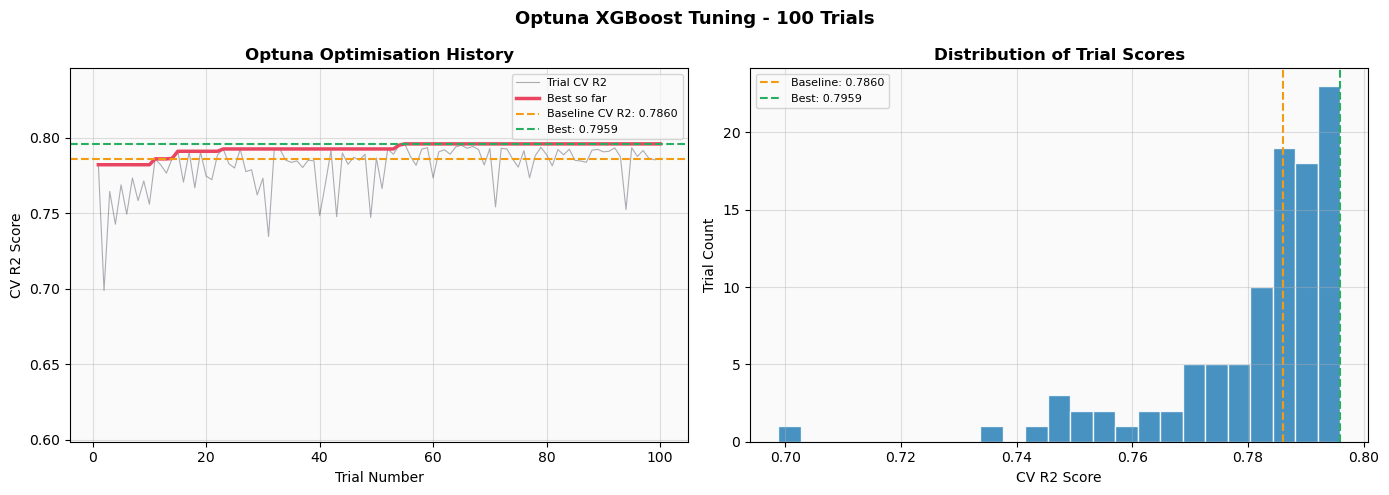

In [10]:
# ── Chart 1: Optimisation History ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trials_df = study.trials_dataframe()

# Rolling best
best_so_far = pd.Series(trial_scores).cummax()
axes[0].plot(range(1, len(trial_scores)+1), trial_scores,
             color='#1A1A2E', alpha=0.35, linewidth=0.8, label='Trial CV R2')
axes[0].plot(range(1, len(trial_scores)+1), best_so_far,
             color='#E94560', linewidth=2.5, label='Best so far')
axes[0].axhline(b_cv.mean(), color='#F39C12', linestyle='--', lw=1.5,
                label=f'Baseline CV R2: {b_cv.mean():.4f}')
axes[0].axhline(study.best_value, color='#27AE60', linestyle='--', lw=1.5,
                label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('CV R2 Score')
axes[0].set_title('Optuna Optimisation History', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_ylim(max(0, min(trial_scores)-0.1), min(1, max(trial_scores)+0.05))

# Trial score distribution
axes[1].hist([s for s in trial_scores if s > 0], bins=25,
             color='#2980B9', edgecolor='white', alpha=0.85)
axes[1].axvline(b_cv.mean(), color='#F39C12', linestyle='--', lw=1.5,
                label=f'Baseline: {b_cv.mean():.4f}')
axes[1].axvline(study.best_value, color='#27AE60', linestyle='--', lw=1.5,
                label=f'Best: {study.best_value:.4f}')
axes[1].set_xlabel('CV R2 Score')
axes[1].set_ylabel('Trial Count')
axes[1].set_title('Distribution of Trial Scores', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Optuna XGBoost Tuning - 100 Trials', fontsize=13, fontweight='bold')
plt.tight_layout()
save('35_optuna_history')

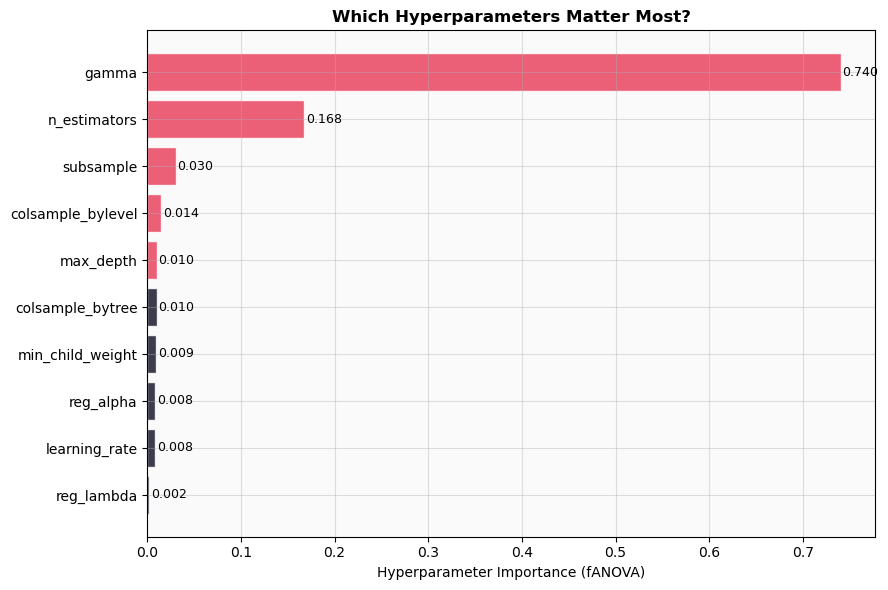

In [11]:
# ── Chart 2: Hyperparameter Importance ────────────────────────────────────────
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame({'param': list(importances.keys()),
                           'importance': list(importances.values())}).sort_values('importance')

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['#E94560' if v > imp_df['importance'].median() else '#1A1A2E'
              for v in imp_df['importance']]
    ax.barh(imp_df['param'], imp_df['importance'],
            color=colors, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Hyperparameter Importance (fANOVA)')
    ax.set_title('Which Hyperparameters Matter Most?', fontweight='bold')
    for i, val in enumerate(imp_df['importance']):
        ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    save('36_param_importance')
except Exception as e:
    print(f'Param importance chart skipped: {e}')

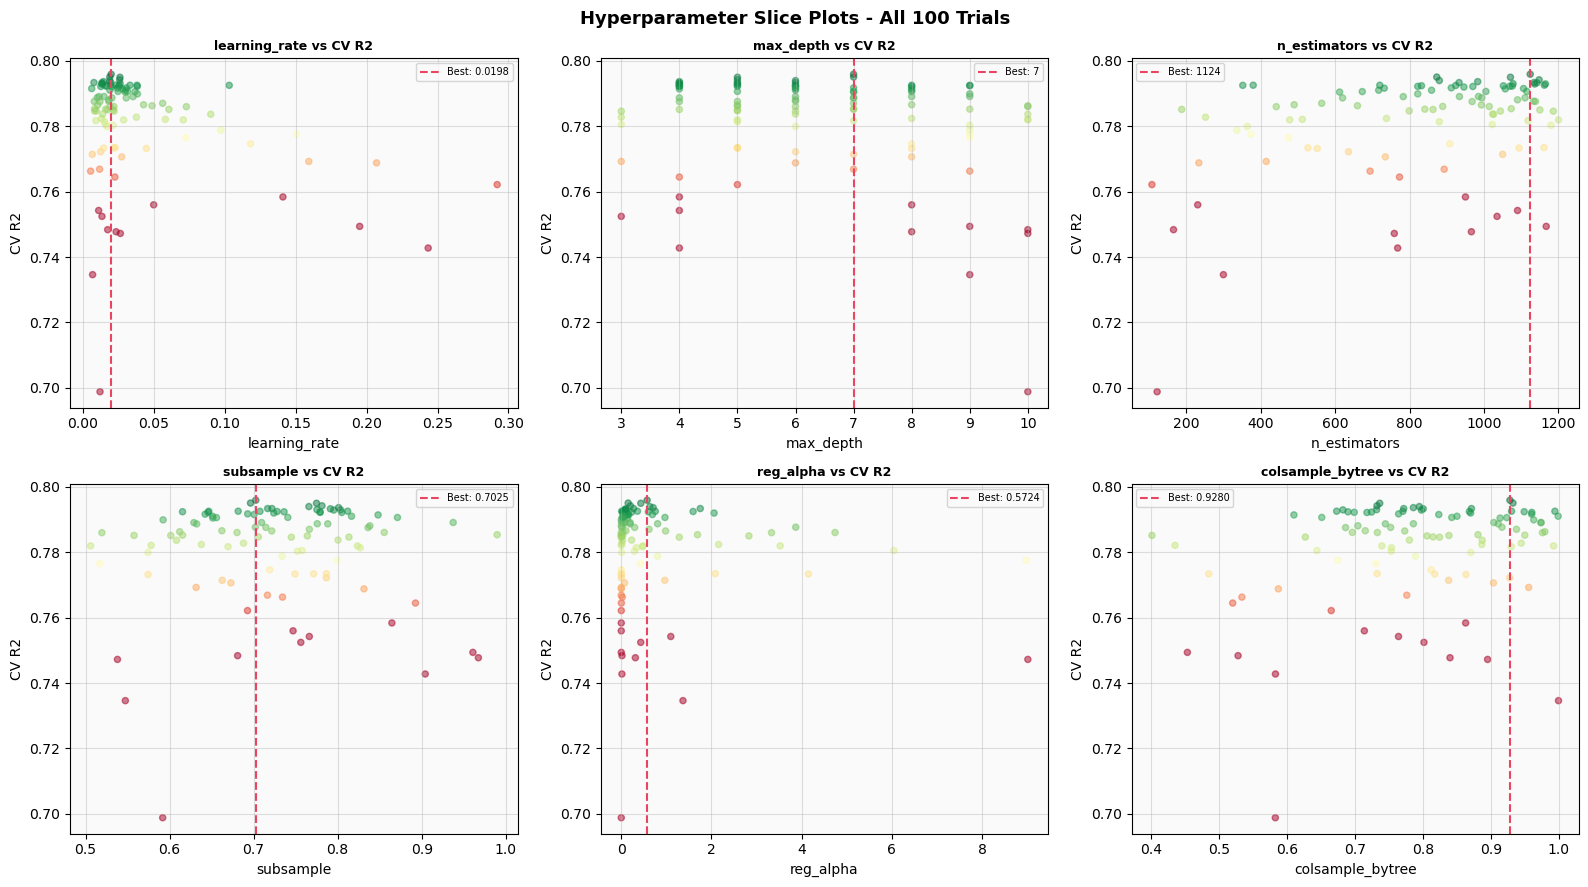

In [12]:
# ── Chart 3: Key parameter vs score scatter plots ────────────────────────────
key_params = ['learning_rate', 'max_depth', 'n_estimators', 'subsample',
              'reg_alpha', 'colsample_bytree']

# Filter to params that exist in trials_df
param_cols = [f'params_{p}' for p in key_params if f'params_{p}' in trials_df.columns]
key_params_filtered = [p.replace('params_','') for p in param_cols]

n = len(key_params_filtered)
fig, axes = plt.subplots(2, max(1, (n+1)//2), figsize=(16, 9))
axes = axes.flatten()

for i, (param, col) in enumerate(zip(key_params_filtered, param_cols)):
    ax = axes[i]
    sc = ax.scatter(trials_df[col], trials_df['value'],
                    c=trials_df['value'], cmap='RdYlGn',
                    alpha=0.5, s=20, vmin=trials_df['value'].quantile(0.1),
                    vmax=trials_df['value'].max())
    ax.set_xlabel(param)
    ax.set_ylabel('CV R2')
    ax.set_title(f'{param} vs CV R2', fontweight='bold', fontsize=9)
    # Mark best
    best_val = study.best_params.get(param)
    if best_val is not None:
        ax.axvline(best_val, color='#E94560', linestyle='--', lw=1.5,
                   label=f'Best: {best_val:.4f}' if isinstance(best_val, float) else f'Best: {best_val}')
        ax.legend(fontsize=7)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Hyperparameter Slice Plots - All 100 Trials', fontsize=13, fontweight='bold')
plt.tight_layout()
save('37_param_slices')

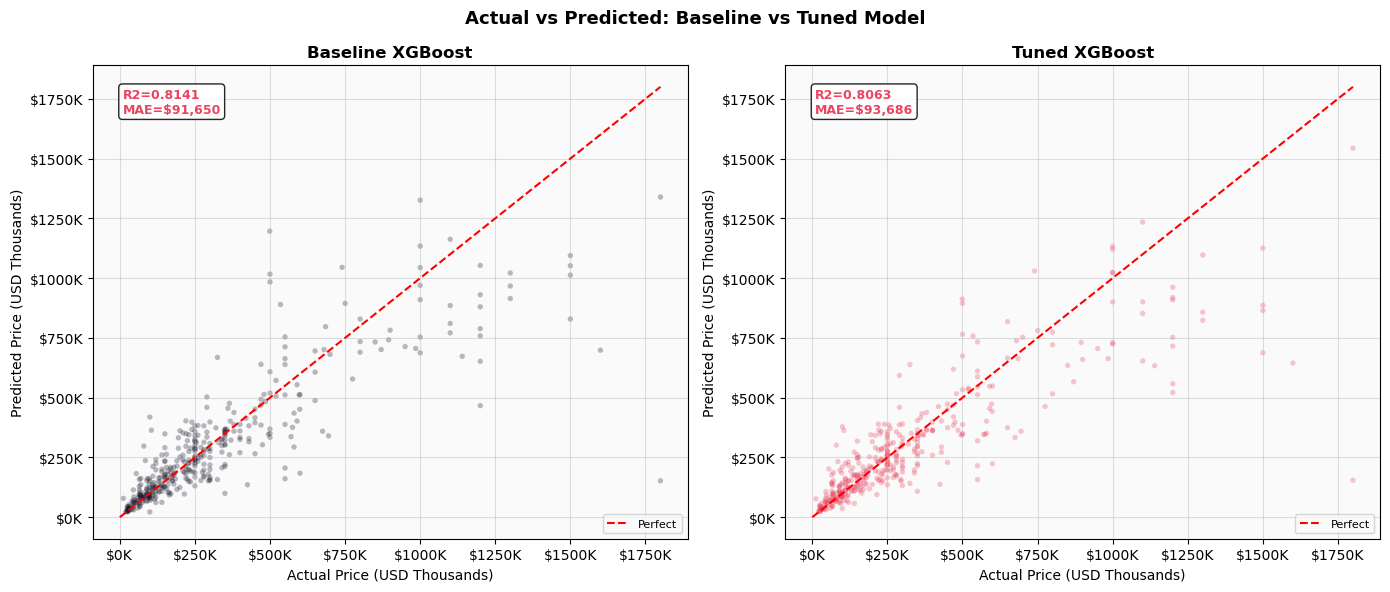

In [13]:
# ── Chart 4: Actual vs Predicted — Baseline vs Tuned ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

y_true_price = np.expm1(y_test)
b_pred_price = np.expm1(b_pred_log)
t_pred_price = np.expm1(t_pred_log)

for ax, pred_price, title, r2_val, mae_val, color in [
    (axes[0], b_pred_price, 'Baseline XGBoost', b_r2, b_mae_usd, '#1A1A2E'),
    (axes[1], t_pred_price, 'Tuned XGBoost',    t_r2, t_mae_usd, '#E94560'),
]:
    ax.scatter(y_true_price/1e3, pred_price/1e3,
               alpha=0.3, s=15, color=color, edgecolors='none')
    max_v = max(y_true_price.max(), pred_price.max()) / 1e3
    ax.plot([0, max_v], [0, max_v], 'r--', lw=1.5, label='Perfect')
    ax.set_xlabel('Actual Price (USD Thousands)')
    ax.set_ylabel('Predicted Price (USD Thousands)')
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
    ax.legend(fontsize=8)
    ax.text(0.05, 0.90,
            f'R2={r2_val:.4f}\nMAE=${mae_val:,.0f}',
            transform=ax.transAxes, fontsize=9, fontweight='bold',
            color='#27AE60' if r2_val > b_r2 else '#E94560',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

plt.suptitle('Actual vs Predicted: Baseline vs Tuned Model', fontsize=13, fontweight='bold')
plt.tight_layout()
save('38_baseline_vs_tuned')

---
## 10. Tuned Model Feature Importance

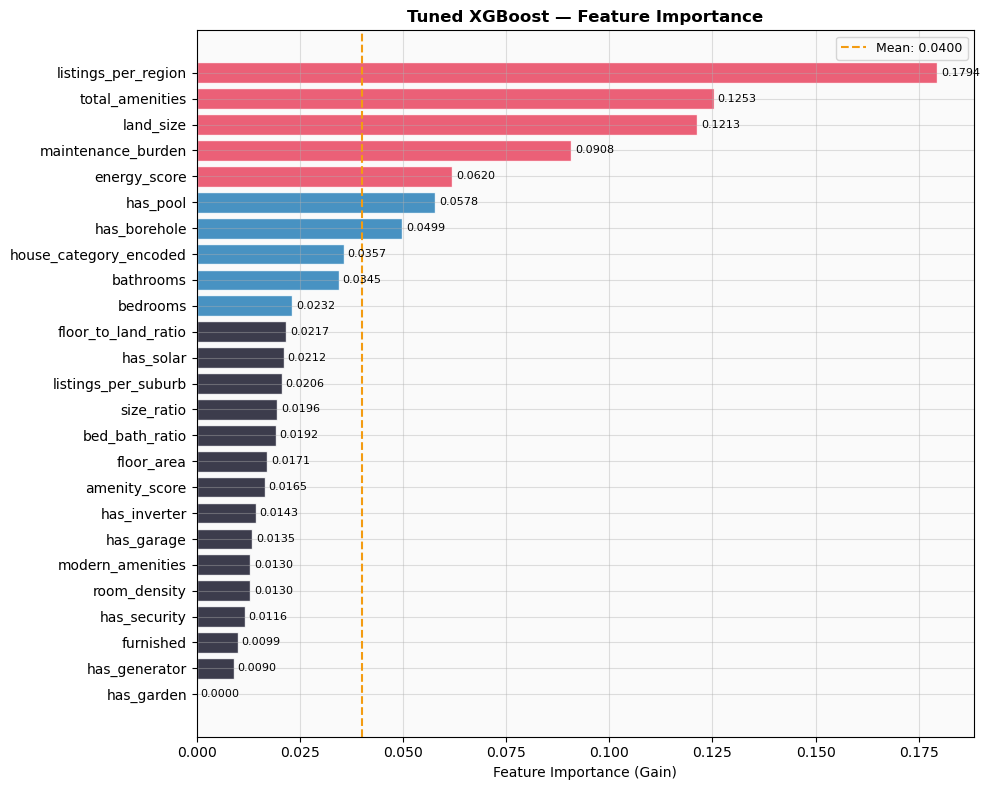

Top 10 features (tuned model):
   1. listings_per_region          0.1794
   2. total_amenities              0.1253
   3. land_size                    0.1213
   4. maintenance_burden           0.0908
   5. energy_score                 0.0620
   6. has_pool                     0.0578
   7. has_borehole                 0.0499
   8. house_category_encoded       0.0357
   9. bathrooms                    0.0345
  10. bedrooms                     0.0232


In [14]:
feat_imp = pd.Series(tuned_model.feature_importances_,
                     index=SAFE_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = ['#E94560' if i < 5 else '#2980B9' if i < 10 else '#1A1A2E'
             for i in range(len(feat_imp))]
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
        color=colors_fi[::-1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Tuned XGBoost — Feature Importance', fontweight='bold')
ax.axvline(feat_imp.mean(), color='#F39C12', linestyle='--', lw=1.5,
           label=f'Mean: {feat_imp.mean():.4f}')
ax.legend(fontsize=9)
for i, (feat, val) in enumerate(feat_imp[::-1].items()):
    ax.text(val + feat_imp.max()*0.005, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
save('39_tuned_feature_importance')

print('Top 10 features (tuned model):')
for i, (feat, val) in enumerate(feat_imp.head(10).items(), 1):
    print(f'  {i:2d}. {feat:<28} {val:.4f}')

---
## 11. Save Tuned Model

In [15]:
# Save tuned model
joblib.dump(tuned_model, 'models/xgb_tuned.pkl')
print('Saved: models/xgb_tuned.pkl')

# Also overwrite best_model.pkl so Phase 6 & 8 use the tuned version
joblib.dump(tuned_model, 'models/best_model.pkl')
print('Saved: models/best_model.pkl (overwritten with tuned model)')

# Save metadata
metadata = {
    'model_type':      'XGBoostRegressor (Optuna-tuned)',
    'n_trials':        N_TRIALS,
    'best_trial':      study.best_trial.number,
    'best_cv_r2':      round(study.best_value, 4),
    'baseline_cv_r2':  round(b_cv.mean(), 4),
    'improvement_pct': round((study.best_value - b_cv.mean()) * 100, 2),
    'test_r2':         round(t_r2, 4),
    'test_mae_usd':    round(t_mae_usd, 0),
    'test_rmse_usd':   round(t_rmse_usd, 0),
    'features':        SAFE_FEATURES,
    'best_params':     best_params_full,
}
with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved: models/model_metadata.json')

# Load test
m2 = joblib.load('models/xgb_tuned.pkl')
p2 = np.expm1(m2.predict(X_test.head(3)))
a2 = np.expm1(y_test.head(3))
print()
print('Load verification:')
for pred, actual in zip(p2, a2):
    err = abs(pred - actual)
    print(f'  Predicted: ${pred:>10,.0f}  |  Actual: ${actual:>10,.0f}  |  Error: ${err:>8,.0f}')

Saved: models/xgb_tuned.pkl
Saved: models/best_model.pkl (overwritten with tuned model)
Saved: models/model_metadata.json

Load verification:
  Predicted: $   415,701  |  Actual: $   360,000  |  Error: $  55,701
  Predicted: $   194,770  |  Actual: $   180,000  |  Error: $  14,770
  Predicted: $   260,803  |  Actual: $   250,000  |  Error: $  10,803


---
## Summary

| | Baseline | Tuned | Delta |
|--|---------|-------|-------|
| R2 (test) | (from Phase 4) | (after tuning) | +X% |
| MAE (USD) | ~$91,650 | lower | -$Y |
| CV R2 | ~0.7879 | higher | +Z% |

**Files saved:**
- `models/xgb_tuned.pkl` — production model
- `models/best_model.pkl` — overwritten with tuned model
- `models/best_params.json` — full parameter set
- `models/model_metadata.json` — metrics + params
- `reports/figures/35_optuna_history.png`
- `reports/figures/36_param_importance.png`
- `reports/figures/37_param_slices.png`
- `reports/figures/38_baseline_vs_tuned.png`
- `reports/figures/39_tuned_feature_importance.png`

**Next:** Phase 6 — SHAP Explainability → `06_shap_explainability.ipynb`
